In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Importing the function library which contains only one class
from function_library_OOP import DetectorSetup

## Global variables and detector initialization

<img src="Detector_setup.png" alt="drawing" width="800"/>

### Variables for intialising a detector setup:

- Radial positions of each detector layer in meters according to the above picture (origin is the interaction point or primary vertex, same coordinate system as used in ALICE). Can be a list or numpy array.
- Thickness of each detector layer in units of radiation length (spatial thickness of layer divided by the radiation length of the detector material). Can be a list or numpy array.
- Spatial resolution of each detector layer in transversal direction in meters (so in rphi or xy, see picture a)). Can be a list or numpy array.
- Spatial resolution of each detector layer in longitudinal direction in meters (so in z, see picture b)). Can be a list or numpy array.
- Radiation length of the medium in between the layers in meters (for air : $303.9$)
- Strength of the magentic field in Tesla (see $B_0$ in the picture)

All these variables have to be passed to the constructor which was imported one cell above. If all went well the message "Detector Setup intialized" will appear.
Below is an example according to the ITS2 detector currently used in ALICE.

In [3]:
average_layer_radii_ITS2 = np.array([23, 31, 39, 196, 245, 344, 393]) * 10**-3               # average radius of ITS2 layers in meters
layerthickness_ITS2 = [0.0035, 0.0035, 0.0035, 0.0110, 0.0110, 0.0110, 0.0110]               # thickness of the detector planes in units of radiation length 0.35% X0 inner and 1.1% X0 outer
detector_resolutions_rphi_ITS2 = np.array([5, 5, 5, 5, 5, 5, 5]) * 10**-6                    # spatial resolution of the ITS2 layers in rphi in meters
detector_resolutions_z_ITS2 = np.array([5, 5, 5, 5, 5, 5, 5]) * 10**-6                       # spatial resolution of the ITS2  layers in z    in meters
radiation_length_air_ITS2 = 303.9                                                            # radiation length of air in meters
magnetic_field_strength_ITS2 = 0.5                                                           # strength of magnetic field in Alice in Tesla

ITS2 = DetectorSetup(average_layer_radii_ITS2, layerthickness_ITS2, detector_resolutions_rphi_ITS2, detector_resolutions_z_ITS2, radiation_length_air_ITS2, magnetic_field_strength_ITS2)

Detector Setup initialized


### Defining particle track:

- Mass of the particle in GeV/c
- Transverse momentum of the particle in GeV/c²
- Number of layers in which the particle has hits (in the current implementation this will the correspond to the last n layers which were defined earlier)
- Extrapolation length in meters (in the current implementation this is defined away from layers with hits)
- Polar angle of the particle in the detector (see coordinate system in picture a))

The example below defines a proton which has hits in the 4 outermost layers of the ITS2 setup and is extrapolated 1cm away from the layers with hits. Here in the example the momentum is defined as an array over which will looped later.

In [9]:
proton_momenta = np.arange(0.1, 10, 0.1)                     # transverse momentum of particle in GeV/c
proton_mass = 1                                             # mass of particle in GeV/c^2 

N = 4                                                       # Number of layers with hits (last 4 layers of the detector in this case)
extrapolation_length = 0.01                                 # extrapolation length in meters (is defined away from layers with hits / away from the IU layer) ;
theta = 90                                                  # polar angles of the particle (test case = 90°, at mid-rapidity)

### Calclating track position and transverse momentum uncertainties of the defined track in the detector setup

Returns the values for the track position uncertainties in meters and for the transverse momentum the method returns the realtive uncertainty (transverse momentum uncertainty divided by transverse momentum) and is therefore unitless.

In [10]:
proton_rphi_4hits = np.array([ITS2.transverse_track_position_uncertainty(momentum, proton_mass, N, extrapolation_length, theta) for momentum in proton_momenta])
print(proton_rphi_4hits.shape)
# print(proton_rphi_4hits)

proton_z_4hits = np.array([ITS2.longitudinal_track_position_uncertainty(momentum, proton_mass, N, extrapolation_length, theta) for momentum in proton_momenta])

proton_pT_4hits = np.array([ITS2.transverse_momentum_reso(momentum, proton_mass, N, theta) for momentum in proton_momenta])

(99,)


### Plotting

Here again since i calculated for a few values of transverse momentum i can nicely plot the quantities against said values of transverse momentum

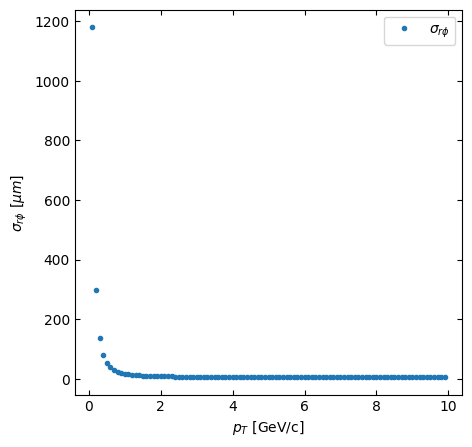

In [11]:
rescaling_factor = 10**6                                # rescaling factor to convert meters to micrometers
plt.rcParams["figure.figsize"] = (5,5)
plt.plot(proton_momenta, proton_rphi_4hits*rescaling_factor, ".", label=r"$\sigma_{r \phi}$")
plt.legend()
plt.xlabel(r"$p_{T}$ [GeV/c]")
plt.ylabel(r"$\sigma_{r \phi}$ [$\mu m$]")
# plt.text(2.5, 1000, f"Proton with {N} hits")
# plt.text(2.5, 950, fr"$\theta = {theta}$°")
# plt.text(2.5, 900, fr"$r = {extrapolation_length*100}$ cm")
plt.tick_params(top=True, right=True, direction="in")

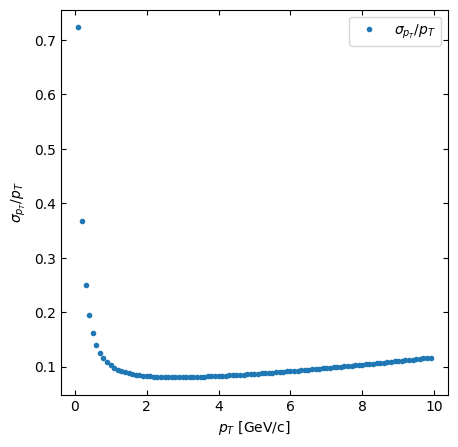

In [12]:
plt.plot(proton_momenta, proton_pT_4hits, ".", label=r"$\sigma_{p_{T}} / p_T$")
plt.legend()
plt.xlabel(r"$p_{T}$ [GeV/c]")
plt.ylabel(r"$\sigma_{p_{T}} / p_T$")
# plt.text(2.5, 1000, f"Proton with {N} hits")
# plt.text(2.5, 950, fr"$\theta = {theta}$°")
# plt.text(2.5, 900, fr"$r = {extrapolation_length*100}$ cm")
plt.tick_params(top=True, right=True, direction="in")

### Interesting stuff

The is the possibilty to perform all calculations without Multiple scattering in the medium in between the layers (by default this option is true). This option would correspond to the medium being a perfect vacuum or just neglecting Multiple scattering in between the layers.

In [8]:
ITS2 = DetectorSetup(average_layer_radii_ITS2, layerthickness_ITS2, detector_resolutions_rphi_ITS2, detector_resolutions_z_ITS2, radiation_length_air_ITS2, magnetic_field_strength_ITS2)
print(ITS2.MS_in_medium)

ITS2.MS_in_medium = False
print(ITS2.MS_in_medium)

Detector Setup initialized
True
False
